<a href="https://colab.research.google.com/github/SPraveeen/Data_engineering_Notes/blob/main/project_stock_market.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import yfinance as yf
import pandas as pd

In [ ]:
stocks=['AAPL','GOOG','MSFT']

start_date='2019-01-01'
end_date='2024-01-01'

In [ ]:
stock_data=yf.download(stocks,start=start_date,end=end_date)

/tmp/ipykernel_335/143618510.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_data=yf.download(stocks,start=start_date,end=end_date)
[*********************100%***********************]  3 of 3 completed


In [ ]:
type(stock_data)

pandas.core.frame.DataFrame

In [ ]:
stock_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1258 entries, 2019-01-02 to 2023-12-29
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   1258 non-null   float64
 1   (Close, GOOG)   1258 non-null   float64
 2   (Close, MSFT)   1258 non-null   float64
 3   (High, AAPL)    1258 non-null   float64
 4   (High, GOOG)    1258 non-null   float64
 5   (High, MSFT)    1258 non-null   float64
 6   (Low, AAPL)     1258 non-null   float64
 7   (Low, GOOG)     1258 non-null   float64
 8   (Low, MSFT)     1258 non-null   float64
 9   (Open, AAPL)    1258 non-null   float64
 10  (Open, GOOG)    1258 non-null   float64
 11  (Open, MSFT)    1258 non-null   float64
 12  (Volume, AAPL)  1258 non-null   int64  
 13  (Volume, GOOG)  1258 non-null   int64  
 14  (Volume, MSFT)  1258 non-null   int64  
dtypes: float64(12), int64(3)
memory usage: 157.2 KB


In [ ]:
stock_data.head(4)

Price           Close                             High                        \
Ticker           AAPL       GOOG       MSFT       AAPL       GOOG       MSFT   
Date                                                                           
2019-01-02  37.503735  51.866680  94.397156  37.724598  52.187547  94.985268   
2019-01-03  33.768078  50.389305  90.924469  34.606402  52.418642  93.528980   
2019-01-04  35.209610  53.099556  95.153282  35.278483  53.106003  95.694723   
2019-01-07  35.131252  52.984501  95.274673  35.344992  53.262719  96.404227   

Price             Low                             Open                        \
Ticker           AAPL       GOOG       MSFT       AAPL       GOOG       MSFT   
Date                                                                           
2019-01-02  36.627412  50.371952  92.362090  36.784153  50.414601  92.931536   
2019-01-03  33.722955  50.290613  90.737762  34.193175  51.626148  93.444960   
2019-01-04  34.150426  50.952582  92.352734  34.323790  51.209078  93.090213   
2019-01-07  34.649157  52.308551  94.266481  35.314117  53.138737  94.882598   

Price          Volume                      
Ticker           AAPL      GOOG      MSFT  
Date                                       
2019-01-02  148158800  30652000  35329300  
2019-01-03  365248800  36822000  42579100  
2019-01-04  234428400  41878000  44060600  
2019-01-07  219111200  39638000  35656100

In [ ]:
stock_data.to_csv('stock_data.csv')

In [ ]:
df=pd.read_csv('stock_data.csv',index_col='High',parse_dates=True)

/tmp/ipykernel_335/3307395801.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df=pd.read_csv('stock_data.csv',index_col='High',parse_dates=True)


In [ ]:
stock_data['High']

Ticker,AAPL,GOOG,MSFT
Date,,,
2019-01-02,37.724598,52.187547,94.985268
2019-01-03,34.606402,52.418642,93.528980
2019-01-04,35.278483,53.106003,95.694723
2019-01-07,35.344992,53.262719,96.404227
2019-01-08,36.055072,53.786412,97.057674
...,...,...,...
2023-12-22,193.400854,142.083529,368.826479
2023-12-26,191.896469,142.772852,370.556726
2023-12-27,191.510500,142.152950,368.708485


In [ ]:
stock_data['High'].info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1258 entries, 2019-01-02 to 2023-12-29
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AAPL    1258 non-null   float64
 1   GOOG    1258 non-null   float64
 2   MSFT    1258 non-null   float64
dtypes: float64(3)
memory usage: 39.3 KB


In [ ]:
df=stock_data.stack(level=0).reset_index()

/tmp/ipykernel_335/378713873.py:1: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  df=stock_data.stack(level=0).reset_index()


In [ ]:
df

Ticker,Date,Price,AAPL,GOOG,MSFT
0,2019-01-02,Close,3.750373e+01,5.186668e+01,9.439716e+01
1,2019-01-02,High,3.772460e+01,5.218755e+01,9.498527e+01
2,2019-01-02,Low,3.662741e+01,5.037195e+01,9.236209e+01
3,2019-01-02,Open,3.678415e+01,5.041460e+01,9.293154e+01
4,2019-01-02,Volume,1.481588e+08,3.065200e+07,3.532930e+07
...,...,...,...,...,...
6285,2023-12-29,Close,1.905505e+02,1.397824e+02,3.696719e+02
6286,2023-12-29,High,1.924012e+02,1.402833e+02,3.707729e+02
6287,2023-12-29,Low,1.897587e+02,1.387608e+02,3.671553e+02
6288,2023-12-29,Open,1.919064e+02,1.395344e+02,3.696326e+02


In [ ]:
closing_price=df[df['Price']=='Close']

In [ ]:
closing_price

Ticker,Date,Price,AAPL,GOOG,MSFT
0,2019-01-02,Close,37.503735,51.866680,94.397156
5,2019-01-03,Close,33.768078,50.389305,90.924469
10,2019-01-04,Close,35.209610,53.099556,95.153282
15,2019-01-07,Close,35.131252,52.984501,95.274673
20,2019-01-08,Close,35.800961,53.375782,95.965462
...,...,...,...,...,...
6265,2023-12-22,Close,191.609467,141.557846,368.236633
6270,2023-12-26,Close,191.065109,141.657013,368.315338
6275,2023-12-27,Close,191.164093,140.288254,367.735260
6280,2023-12-28,Close,191.589676,140.129532,368.924805


In [ ]:
closing_price.drop(columns='Price',inplace=True)

/tmp/ipykernel_335/4244965042.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  closing_price.drop(columns='Price',inplace=True)


In [ ]:
closing_price

Ticker,Date,AAPL,GOOG,MSFT
0,2019-01-02,37.503735,51.866680,94.397156
5,2019-01-03,33.768078,50.389305,90.924469
10,2019-01-04,35.209610,53.099556,95.153282
15,2019-01-07,35.131252,52.984501,95.274673
20,2019-01-08,35.800961,53.375782,95.965462
...,...,...,...,...
6265,2023-12-22,191.609467,141.557846,368.236633
6270,2023-12-26,191.065109,141.657013,368.315338
6275,2023-12-27,191.164093,140.288254,367.735260
6280,2023-12-28,191.589676,140.129532,368.924805


In [ ]:
closing_price.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1258 entries, 0 to 6285
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    1258 non-null   datetime64[ns]
 1   AAPL    1258 non-null   float64       
 2   GOOG    1258 non-null   float64       
 3   MSFT    1258 non-null   float64       
dtypes: datetime64[ns](1), float64(3)
memory usage: 49.1 KB


In [ ]:
closing_price.isna()

Ticker,Date,AAPL,GOOG,MSFT
0,False,False,False,False
5,False,False,False,False
10,False,False,False,False
15,False,False,False,False
20,False,False,False,False
...,...,...,...,...
6265,False,False,False,False
6270,False,False,False,False
6275,False,False,False,False
6280,False,False,False,False


In [ ]:
closing_price.isna().sum()

,0
Ticker,
Date,0
AAPL,0
GOOG,0
MSFT,0


In [ ]:
start_date='2023-01-01'
end_date='2023-12-31'

In [ ]:
filtered_df=closing_price[(closing_price.Date>=start_date) & (closing_price.Date<=end_date)]

In [ ]:
filtered_df

Ticker,Date,AAPL,GOOG,MSFT
5040,2023-01-03,123.096024,88.969574,233.452774
5045,2023-01-04,124.365654,87.987625,223.240829
5050,2023-01-05,123.046799,86.063423,216.624481
5055,2023-01-06,127.574196,87.442116,219.177444
5060,2023-01-09,128.095840,88.076904,221.311462
...,...,...,...,...
6265,2023-12-22,191.609467,141.557846,368.236633
6270,2023-12-26,191.065109,141.657013,368.315338
6275,2023-12-27,191.164093,140.288254,367.735260
6280,2023-12-28,191.589676,140.129532,368.924805


In [ ]:
filtered_df_AAPL=filtered_df[['Date','AAPL']]

In [ ]:
filtered_df_AAPL

Ticker,Date,AAPL
5040,2023-01-03,123.096024
5045,2023-01-04,124.365654
5050,2023-01-05,123.046799
5055,2023-01-06,127.574196
5060,2023-01-09,128.095840
...,...,...
6265,2023-12-22,191.609467
6270,2023-12-26,191.065109
6275,2023-12-27,191.164093
6280,2023-12-28,191.589676


In [ ]:
filtered_df_AAPL['Daily_Returns']=filtered_df['AAPL'].pct_change()

/tmp/ipykernel_335/2328437953.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df_AAPL['Daily_Returns']=filtered_df['AAPL'].pct_change()


In [ ]:
filtered_df_AAPL

Ticker,Date,AAPL,Daily_Returns
5040,2023-01-03,123.096024,NaN
5045,2023-01-04,124.365654,0.010314
5050,2023-01-05,123.046799,-0.010605
5055,2023-01-06,127.574196,0.036794
5060,2023-01-09,128.095840,0.004089
...,...,...,...
6265,2023-12-22,191.609467,-0.005548
6270,2023-12-26,191.065109,-0.002841
6275,2023-12-27,191.164093,0.000518
6280,2023-12-28,191.589676,0.002226


In [ ]:
filtered_df_AAPL['20 day moving average']=filtered_df_AAPL['AAPL'].rolling(window=20).mean()

In [ ]:
filtered_df_AAPL

Ticker,Date,AAPL,Daily_Returns,20 day moving average
5040,2023-01-03,123.096024,NaN,NaN
5045,2023-01-04,124.365654,0.010314,NaN
5050,2023-01-05,123.046799,-0.010605,NaN
5055,2023-01-06,127.574196,0.036794,NaN
5060,2023-01-09,128.095840,0.004089,NaN
...,...,...,...,...
6265,2023-12-22,191.609467,-0.005548,191.677263
6270,2023-12-26,191.065109,-0.002841,191.838586
6275,2023-12-27,191.164093,0.000518,191.974673
6280,2023-12-28,191.589676,0.002226,192.183009


In [ ]:
filtered_df_AAPL['Cummulative_Returns']=(1+filtered_df_AAPL['Daily_Returns']).cumprod()-1

In [ ]:
filtered_df_AAPL

Ticker,Date,AAPL,Daily_Returns,20 day moving average,Cummulative_Returns
5040,2023-01-03,123.096024,NaN,NaN,NaN
5045,2023-01-04,124.365654,0.010314,NaN,0.010314
5050,2023-01-05,123.046799,-0.010605,NaN,-0.000400
5055,2023-01-06,127.574196,0.036794,NaN,0.036380
5060,2023-01-09,128.095840,0.004089,NaN,0.040617
...,...,...,...,...,...
6265,2023-12-22,191.609467,-0.005548,191.677263,0.556585
6270,2023-12-26,191.065109,-0.002841,191.838586,0.552163
6275,2023-12-27,191.164093,0.000518,191.974673,0.552967
6280,2023-12-28,191.589676,0.002226,192.183009,0.556425


In [ ]:
# volatile
volatility=filtered_df_AAPL['Daily_Returns'].std()

In [ ]:
volatility

0.012570052345665963

In [ ]:
filtered_df_GOOG=filtered_df[['Date','GOOG']]
filtered_df_MSFT=filtered_df[['Date','MSFT']]

In [ ]:
filtered_df_GOOG['Daily_Returns']=filtered_df['GOOG'].pct_change()
filtered_df_GOOG['20 day moving average']=filtered_df_GOOG['GOOG'].rolling(window=20).mean()
filtered_df_GOOG['Cummulative_Returns']=(1+filtered_df_GOOG['Daily_Returns']).cumprod()-1

/tmp/ipykernel_335/3436247164.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df_GOOG['Daily_Returns']=filtered_df['GOOG'].pct_change()


In [ ]:
filtered_df_GOOG

Ticker,Date,GOOG,Daily_Returns,20 day moving average,Cummulative_Returns
5040,2023-01-03,88.969574,NaN,NaN,NaN
5045,2023-01-04,87.987625,-0.011037,NaN,-0.011037
5050,2023-01-05,86.063423,-0.021869,NaN,-0.032665
5055,2023-01-06,87.442116,0.016019,NaN,-0.017168
5060,2023-01-09,88.076904,0.007260,NaN,-0.010033
...,...,...,...,...,...
6265,2023-12-22,141.557846,0.006488,134.826585,0.591082
6270,2023-12-26,141.657013,0.000701,135.063142,0.592196
6275,2023-12-27,140.288254,-0.009662,135.202997,0.576812
6280,2023-12-28,140.129532,-0.001131,135.445010,0.575028


In [ ]:
filtered_df_MSFT['Daily_Returns']=filtered_df['MSFT'].pct_change()
filtered_df_MSFT['20 day moving average']=filtered_df_MSFT['MSFT'].rolling(window=20).mean()
filtered_df_MSFT['Cummulative_Returns']=(1+filtered_df_MSFT['Daily_Returns']).cumprod()-1

/tmp/ipykernel_335/1579069327.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df_MSFT['Daily_Returns']=filtered_df['MSFT'].pct_change()


In [ ]:
filtered_df_MSFT

Ticker,Date,MSFT,Daily_Returns,20 day moving average,Cummulative_Returns
5040,2023-01-03,233.452774,NaN,NaN,NaN
5045,2023-01-04,223.240829,-0.043743,NaN,-0.043743
5050,2023-01-05,216.624481,-0.029638,NaN,-0.072084
5055,2023-01-06,219.177444,0.011785,NaN,-0.061149
5060,2023-01-09,221.311462,0.009736,NaN,-0.052008
...,...,...,...,...,...
6265,2023-12-22,368.236633,0.002784,367.203433,0.577350
6270,2023-12-26,368.315338,0.000214,367.009282,0.577687
6275,2023-12-27,367.735260,-0.001575,366.585089,0.575202
6280,2023-12-28,368.924805,0.003235,366.409613,0.580297


In [ ]:
print("Volatility of AAPL: ",filtered_df_AAPL['Daily_Returns'].std())
print("Volatility of MFST: ",filtered_df_MSFT['Daily_Returns'].std())
print("Volatility of GOOG: ",filtered_df_GOOG['Daily_Returns'].std())

Volatility of AAPL:  0.012570052345665963
Volatility of MFST:  0.01582433447885065
Volatility of GOOG:  0.019283266627444774


In [ ]:
print("CR of AAPL: ",filtered_df_AAPL['Cummulative_Returns'].iloc[-1])
print("CR of MFST: ",filtered_df_MSFT['Cummulative_Returns'].iloc[-1])
print("CR of GOOG: ",filtered_df_GOOG['Cummulative_Returns'].iloc[-1])

CR of AAPL:  0.5479823845163034
CR of MFST:  0.5834975918590091
CR of GOOG:  0.5711254718550538


In [ ]:
import matplotlib.pyplot as plt

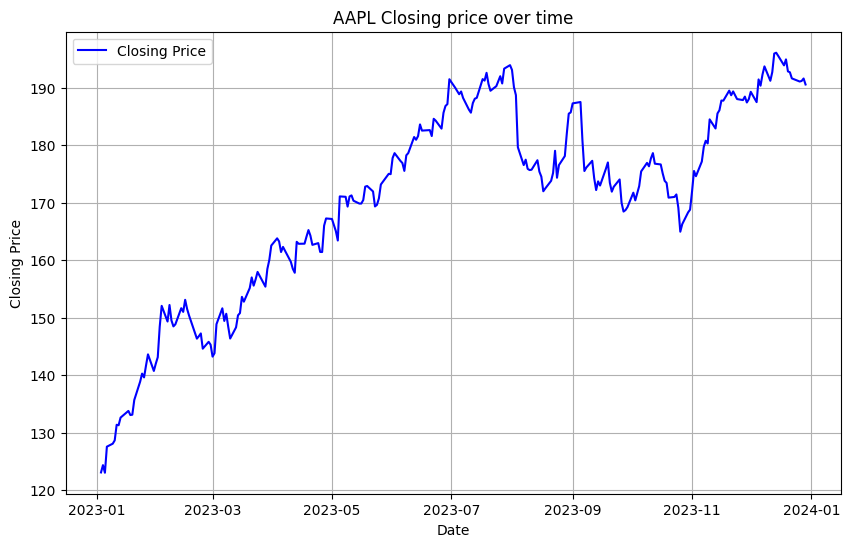

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(filtered_df_AAPL['Date'],filtered_df_AAPL['AAPL'],label='Closing Price',color='blue')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.title('AAPL Closing price over time')
plt.legend()
plt.grid(True)
plt.show()

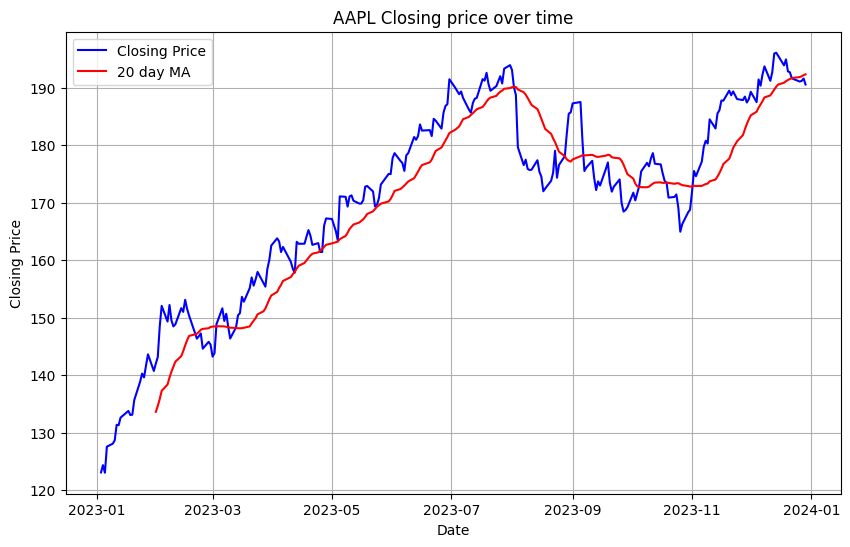

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(filtered_df_AAPL['Date'],filtered_df_AAPL['AAPL'],label='Closing Price',color='blue')
plt.plot(filtered_df_AAPL['Date'],filtered_df_AAPL['20 day moving average'],label='20 day MA',color='red')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.title('AAPL Closing price over time')
plt.legend()
plt.grid(True)
plt.show()

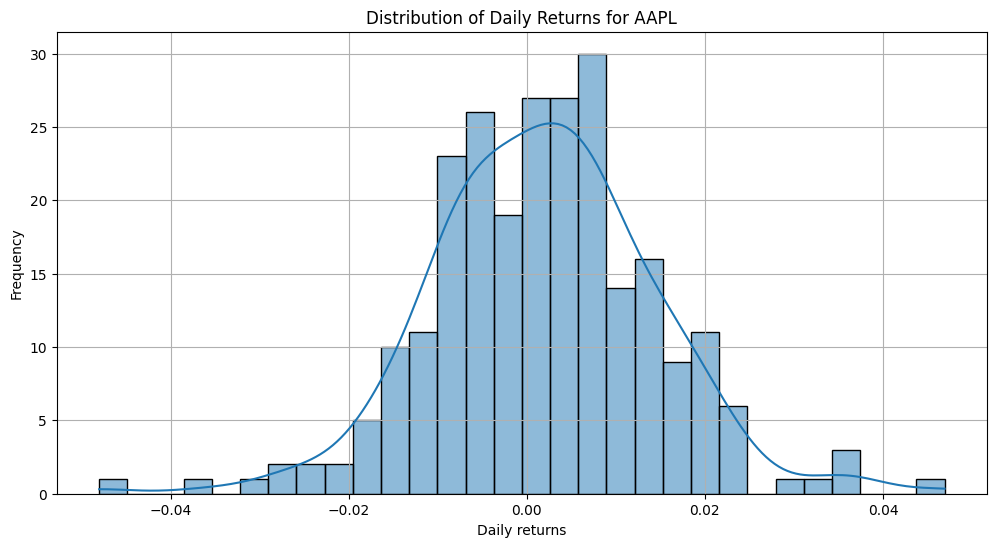

In [ ]:
import seaborn as sns

plt.figure(figsize=(12,6))
sns.histplot(filtered_df_AAPL['Daily_Returns'].dropna(),bins=30,kde=True)
plt.xlabel('Daily returns')
plt.ylabel('Frequency')
plt.title('Distribution of Daily Returns for AAPL')
plt.grid(True)
plt.show()